# Régression linéaire simple — CO₂ et masse des véhicules

Premier notebook du cours *Machine Learning Specialization* (DeepLearning.AI, cours 1 — semaine 1), appliqué au jeu de données ADEME des émissions des véhicules commercialisés en France.

**Question** : la masse d'un véhicule suffit-elle à prédire ses émissions de CO₂ ?

Le notebook est en deux temps. La **partie I** répond à la question avec scikit-learn : ce que la masse explique, et où elle échoue. La **partie II** ouvre la boîte noire — fonction de coût, descente de gradient, taux d'apprentissage, normalisation — en réimplémentant à la main ce que scikit-learn fait en trois lignes.

La méthode est d'abord construite à la main sur les véhicules **diesel**, puis appliquée telle quelle aux véhicules **essence**. Le second passage n'est pas une répétition : c'est là que le modèle révèle ses limites, et qu'apparaît une famille de véhicules qu'une seule variable ne peut pas décrire.

**Données** : `data/vehicules.csv` — ADEME 2014, via [data.gouv.fr](https://www.data.gouv.fr/datasets/emissions-de-co2-et-de-polluants-des-vehicules-commercialises-en-france).

## Partie I — Ce que disent les données

### 1. Chargement et préparation

Les colonnes texte contiennent des espaces de fin (export à format fixe), invisibles à l'affichage mais bloquants pour toute comparaison — d'où le `.str.strip()` sur `energ`, la colonne dont dépend le filtrage.

Deux fonctions évitent de dupliquer le code entre motorisations : la masse est convertie en tonnes, ce qui rend `w` directement lisible en grammes de CO₂ par kilomètre et par tonne.

In [24]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("data/vehicules.csv", sep=";", encoding="latin-1")
df["energ"] = df["energ"].str.strip()

MOTORISATIONS = {"GO": "Diesel", "ES": "Essence"}

def preparer(code):
    """Retourne (masse en tonnes, CO2 en g/km) pour une motorisation."""
    d = df[df["energ"] == code][["masse_ordma_min", "co2_mixte"]].dropna()
    return d["masse_ordma_min"].values / 1000, d["co2_mixte"].values

def ajuster(x, y):
    """Ajuste une régression linéaire simple et retourne le modèle et ses prédictions."""
    X = x.reshape(-1, 1)          # scikit-learn attend un tableau 2D
    model = LinearRegression().fit(X, y)
    return model, model.predict(X)

x_go, y_go = preparer("GO")
print(f"{len(x_go)} véhicules diesel")

12675 véhicules diesel


### 2. Le modèle codé à la main

La fonction `compute_model_output` du cours fonctionne directement, sans modification.

In [25]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

#### Première droite, paramètres devinés

Nuage de points `masse_ordma_min` / `co2_mixte`, avec la droite produite par `compute_model_output` pour des valeurs de `w` et `b` choisies à la main.

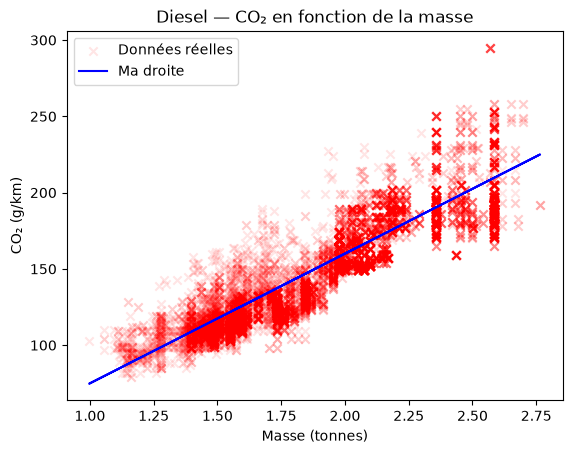

In [26]:
w_devine, b_devine = 85, -10   # valeurs cherchées à tâtons

plt.scatter(x_go, y_go, marker="x", c="r", alpha=0.1, label="Données réelles")
plt.plot(x_go, compute_model_output(x_go, w_devine, b_devine), c="b", label="Ma droite")
plt.title("Diesel — CO₂ en fonction de la masse")
plt.xlabel("Masse (tonnes)"); plt.ylabel("CO₂ (g/km)"); plt.legend()
plt.show()

### 3. Le même modèle avec scikit-learn

En pratique, on utilise **scikit-learn**. Je prends l'habitude de refaire chaque algorithme du cours avec scikit-learn une fois que je l'ai compris : trois lignes au lieu de trente.

In [27]:
model_go, pred_go = ajuster(x_go, y_go)
print(f"w = {model_go.coef_[0]:.2f}   b = {model_go.intercept_:.2f}")

w = 83.65   b = -11.09


Mes valeurs devinées de `w` et `b` (85 et -10) tombaient à moins de 2 % des valeurs optimales calculées par scikit-learn : le tâtonnement à l'œil n'est pas absurde sur une seule variable. Il le devient dès qu'il y en a trois.

#### Observation

Le nuage s'évase : une seule variable ne suffit pas à expliquer les émissions. C'est exactement le problème que résout la **régression multiple** (semaine 2), où je pourrai combiner masse, puissance et type de boîte.

### 4. Ce que `w` et `b` signifient

**w ≈ 83,65** — chaque tonne supplémentaire ajoute environ 84 g de CO₂ par kilomètre. Un chiffre
concret et interprétable, précisément parce que j'ai converti la masse en tonnes : en kilogrammes,
j'aurais eu `w = 0,0837`, exact mais illisible.

**b ≈ -11,09** — plus délicat : c'est le CO₂ prédit pour un véhicule de masse nulle, ce qui n'a aucun
sens physique, et il est négatif, ce qui en a encore moins. C'est normal : l'ordonnée à l'origine est
un paramètre d'ajustement de la droite, pas une grandeur physique. Extrapoler un modèle hors de la
plage des données (ici 1 à 2,75 t) donne des résultats absurdes. Bon réflexe à garder.

### 5. Diesel contre essence

In [28]:
resultats = {}
for code, nom in MOTORISATIONS.items():
    x, y = preparer(code)
    model, y_pred = ajuster(x, y)
    resultats[nom] = {
        "x": x, "y": y, "y_pred": y_pred,
        "n": len(x),
        "w (g/km par tonne)": model.coef_[0],
        "b (g/km)": model.intercept_,
        "MAE (g/km)": mean_absolute_error(y, y_pred),
        "R²": r2_score(y, y_pred),
    }

lignes = ["n", "w (g/km par tonne)", "b (g/km)", "MAE (g/km)", "R²"]
pd.DataFrame({nom: {k: r[k] for k in lignes} for nom, r in resultats.items()}).round(3)

,Diesel,Essence
n,12675.000,6934.000
w (g/km par tonne),83.647,135.430
b (g/km),-11.087,-49.129
MAE (g/km),11.368,22.807
R²,0.805,0.621


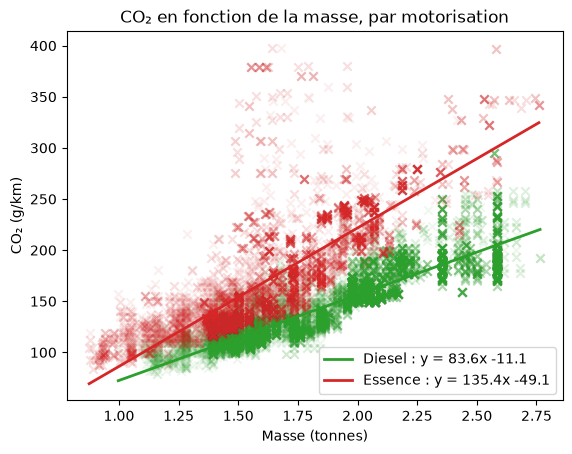

In [29]:
for nom, couleur in [("Diesel", "tab:green"), ("Essence", "tab:red")]:
    r = resultats[nom]
    plt.scatter(r["x"], r["y"], marker="x", alpha=0.08, c=couleur)
    bornes = np.array([r["x"].min(), r["x"].max()])
    droite = r["w (g/km par tonne)"] * bornes + r["b (g/km)"]
    plt.plot(bornes, droite, c=couleur, lw=2, label=f"{nom} : y = {r['w (g/km par tonne)']:.1f}x {r['b (g/km)']:+.1f}")

plt.title("CO₂ en fonction de la masse, par motorisation")
plt.xlabel("Masse (tonnes)"); plt.ylabel("CO₂ (g/km)"); plt.legend()
plt.show()

**Les pentes.** 135 g/km par tonne pour l'essence contre 84 pour le diesel : chez l'essence, chaque tonne supplémentaire coûte bien plus cher en CO₂.

**Le croisement.** Les deux droites se croisent à 0,74 tonne — en dehors de la plage observée. Sur tout le domaine réel (0,875 à 2,75 t), la droite essence reste au-dessus : à masse égale, l'essence émet systématiquement plus, et l'écart se creuse avec le poids (≈ 14 g/km à 1 tonne, ≈ 91 g/km à 2,5 tonnes).

**Le R².** 0,621 pour l'essence contre 0,805 pour le diesel. La masse explique moins bien les émissions des essences, parce que la population est plus hétérogène : de la citadine à la supercar, quand le diesel se concentre sur les berlines et les utilitaires. Plus une population est variée, moins une seule variable suffit à la décrire.

In [30]:
for code, nom in MOTORISATIONS.items():
    x, y = resultats[nom]["x"], resultats[nom]["y"]
    corr = np.corrcoef(x, y)[0, 1]
    print(f"{nom:8s} corr = {corr:.3f}   corr² = {corr**2:.3f}   R² = {resultats[nom]['R²']:.3f}")

Diesel   corr = 0.897   corr² = 0.805   R² = 0.805
Essence  corr = 0.788   corr² = 0.621   R² = 0.621


### 6. Les résidus, ou l'endroit où le modèle se trompe

Le R² dit *combien* le modèle se trompe. Les résidus disent *où* — et c'est là que les deux motorisations divergent vraiment.

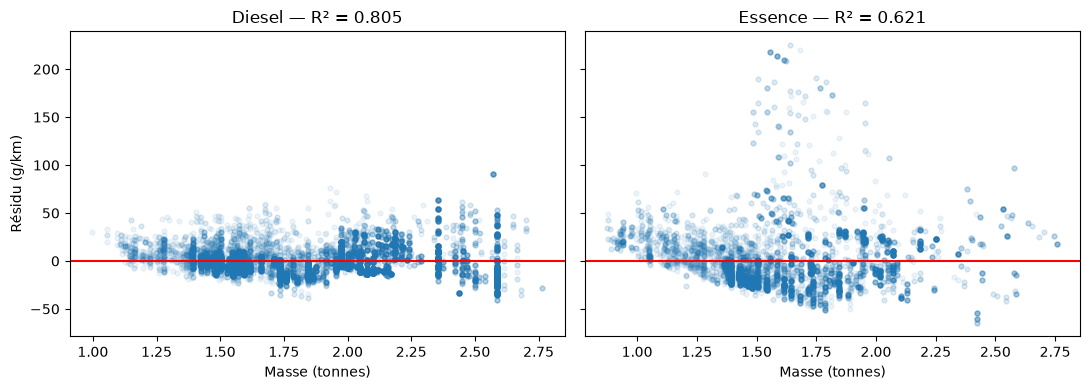

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, nom in zip(axes, resultats):
    r = resultats[nom]
    ax.scatter(r["x"], r["y"] - r["y_pred"], alpha=0.08, s=12)
    ax.axhline(0, c="r")
    ax.set_title(f"{nom} — R² = {r['R²']:.3f}")
    ax.set_xlabel("Masse (tonnes)")

axes[0].set_ylabel("Résidu (g/km)")
plt.tight_layout()
plt.show()

**Diesel** — les erreurs s'évasent vers la droite au lieu de rester constantes: le modèle est moins fiable sur les véhicules lourds.

**Essence** — la dispersion n'est pas symétrique. Une traînée de gros résidus positifs, jusqu'à +220 g/km, se concentre entre 1,5 et 2 tonnes: des véhicules relativement légers qui émettent énormément. Des sportives. Le modèle les sous-estime massivement parce qu'il ne connaît que la masse.

Cela reboucle exactement sur mon [analyse exploratoire](https://github.com/aissatougueye06/analyse-co2-vehicules): j'y avais trouvé une corrélation masse / puissance de seulement 0,21 et j'en avais déduit l'existence de deux familles distinctes de véhicules. Ces points aberrants sont cette seconde famille, qui réapparaît ici sous forme d'erreurs de prédiction.

Vérifions :

In [32]:
es = (df[df["energ"] == "ES"]
      [["lib_mrq_doss", "masse_ordma_min", "co2_mixte", "puiss_max"]]
      .dropna()
      .drop_duplicates())

r = resultats["Essence"]
es["residu"] = es["co2_mixte"] - (r["w (g/km par tonne)"] * es["masse_ordma_min"] / 1000
                                 + r["b (g/km)"])
es.nlargest(10, "residu")

,lib_mrq_doss,masse_ordma_min,co2_mixte,puiss_max,residu
3283,LAMBORGHINI,1640,398.0,545.0,225.022779
3285,LAMBORGHINI,1680,398.0,545.0,219.605566
3877,LEXUS,1555,379.0,412.0,217.534357
3885,LEXUS,1585,379.0,420.0,213.471447
3879,LEXUS,1615,379.0,412.0,209.408538
3887,LEXUS,1625,379.0,420.0,208.054234
13,ALFA ROMEO,1750,379.0,331.0,191.125444
3316,LAMBORGHINI,1505,344.0,419.0,189.305873
3304,LAMBORGHINI,1575,351.0,412.0,186.825751
2214,FERRARI,1791,380.0,541.0,186.572800


Les marques sportives apparaissent en tête, avec des puissances sans commune mesure avec leur masse. Le modèle n'avait aucun moyen de les voir venir.

## Partie II — Sous le capot : d'où viennent w et b

### 7. Fonction de coût

In [33]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    return (1 / (2 * m)) * np.sum((w * x + b - y) ** 2)

In [34]:
print(f"coût final (valeurs devinées) = {compute_cost(x_go, y_go, w_devine, b_devine):.2f}")          # mes valeurs tâtonnées
print(f"coût final (scikit-learn) = {compute_cost(x_go, y_go, model_go.coef_[0], model_go.intercept_):.2f}")    # sklearn

coût final (valeurs devinées) = 121.62
coût final (scikit-learn) = 114.77


### 8. La descente de gradient

In [35]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    erreur = w * x + b - y          # le terme commun aux deux dérivées
    dj_dw = np.sum(erreur * x) / m
    dj_db = np.sum(erreur) / m
    return dj_dw, dj_db

#### Structure du lab de la descente de gradient

In [36]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters,
                     cost_function, gradient_function, verbose=True):
    """Descente de gradient sur une régression linéaire à une variable.

    Retourne les paramètres finaux et l'historique du coût.
    """
    w, b = w_in, b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(cost_function(x, y, w, b))

        if verbose and i % math.ceil(num_iters / 10) == 0:
            print(f"Itération {i:5} : J = {J_history[-1]:0.2e}   w = {w:>10.4g}   b = {b:>10.4g}")

    return w, b, J_history

Application du descente de gradient sur les véhicules diesel `GO`.

In [37]:
w_gd, b_gd, J_hist = gradient_descent(x_go, y_go, 0, 0, 0.01, 10000,
                                      compute_cost, compute_gradient)

print(f"Descente de gradient : w = {w_gd:.2f}, b = {b_gd:.2f}")
print(f"scikit-learn         : w = {model_go.coef_[0]:.2f}, b = {model_go.intercept_:.2f}")

Itération     0 : J = 1.05e+04   w =      2.944   b =      1.484
Itération  1000 : J = 1.33e+02   w =      67.34   b =      20.92
Itération  2000 : J = 1.25e+02   w =       71.4   b =      12.95
Itération  3000 : J = 1.21e+02   w =      74.45   b =      6.961
Itération  4000 : J = 1.18e+02   w =      76.74   b =      2.466
Itération  5000 : J = 1.17e+02   w =      78.46   b =    -0.9099
Itération  6000 : J = 1.16e+02   w =      79.75   b =     -3.445
Itération  7000 : J = 1.15e+02   w =      80.72   b =     -5.348
Itération  8000 : J = 1.15e+02   w =      81.45   b =     -6.778
Itération  9000 : J = 1.15e+02   w =         82   b =     -7.851
Descente de gradient : w = 82.41, b = -8.66
scikit-learn         : w = 83.65, b = -11.09


La descente de gradient se rapproche des valeurs trouvées par scikit-learn, mais inégalement : 1,5 % d'écart sur `w`, 22 % sur `b`. Et la convergence est lente. Le coût atteint 1,15e+02 dès l'itération 7 000 alors que les paramètres continuent de bouger longtemps après : la descente dévale vite les parois, puis rampe le long du fond. La section 10 expliquera pourquoi — et comment y remédier.

### 9. Le taux d'apprentissage

Analysons le comportement de la descente de gradient avec plusieurs valeurs de alpha:

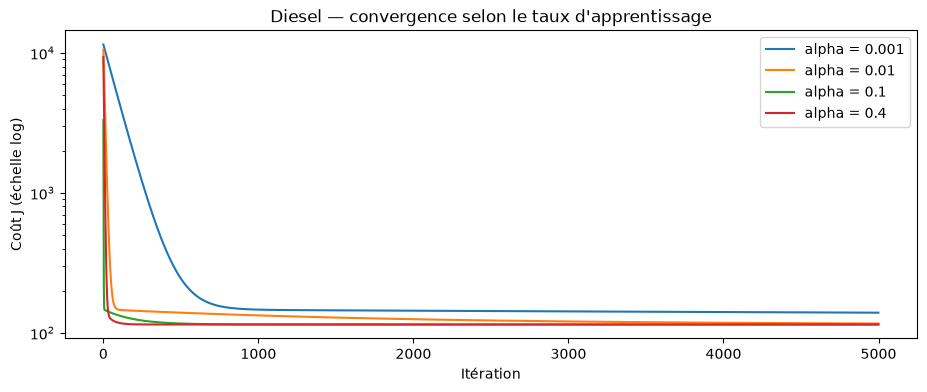

In [47]:
plt.figure(figsize=(11, 4))

for a in [0.001, 0.01, 0.1, 0.4]:
    _, _, J = gradient_descent(x_go, y_go, 0, 0, a, 5000,
                               compute_cost, compute_gradient, verbose=False)
    plt.plot(J, label=f"alpha = {a}")

plt.yscale("log")
plt.xlabel("Itération"); plt.ylabel("Coût J (échelle log)")
plt.title("Diesel — convergence selon le taux d'apprentissage")
plt.legend(); plt.show()

In [48]:
for a in [0.001, 0.01, 0.1, 0.4]:
    w, b, J = gradient_descent(x_go, y_go, 0, 0, a, 20000,
                                  compute_cost, compute_gradient, verbose=False)
    print(f"alpha={a}: w={w:.2f}, b={b:.2f}, J={J[-1]:.2f}")

alpha=0.001: w=71.40, b=12.96, J=125.19
alpha=0.01: w=83.58, b=-10.95, J=114.77
alpha=0.1: w=83.65, b=-11.09, J=114.77
alpha=0.4: w=83.65, b=-11.09, J=114.77


Avec un alpha trop petit `alpha=0.001`, on finit à `w=71,4`, `b=12,96`, `J=125,2`. On tourne 20 000 itérations sans y arriver.
Avec `alpha=0.01`, on se rapproche plus des valeurs correctes pour `w` et `b` mais avec une convergence lente: plus de 20000 itérations. C'est ce que l'on a vu précedemment.
Avec `alpha=0.1`, la convergence est atteinte vers 4000 itérations.
Avec `alpha=0.4`, la convergence est atteinte vers 2000 itérations.

Testons avec des valeurs de alpha plus élevés `alpha=0.46` et `alpha=0.5` pour chercher la limite de convergence.

In [50]:
for a in [0.46, 0.5]:
    w, b, J= gradient_descent(x_go, y_go, 0, 0, a, 20000,
                                  compute_cost, compute_gradient, verbose=False)
    print(f"alpha={a}: w={w:.2f}, b={b:.2f}, J={J[-1]:.2f}")

/Users/aissatougueye/Projets/ml-co2-prediction/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/zz/v3tm43tj7gdgxf08z75tqzrm0000gn/T/ipykernel_75363/2877193615.py:3: RuntimeWarning: overflow encountered in square
  return (1 / (2 * m)) * np.sum((w * x + b - y) ** 2)
/var/folders/zz/v3tm43tj7gdgxf08z75tqzrm0000gn/T/ipykernel_75363/3555387926.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  w -= alpha * dj_dw


alpha=0.46: w=nan, b=nan, J=nan
alpha=0.5: w=nan, b=nan, J=nan


Les valeurs divergent avec un alpha trop grand. Pour `alpha=0.46`, le coût explose et passe de 1.62e+04 à 3.94e+294 à 2000 itérations. Il augmente au lieu de diminuer. Puis `inf`, puis `nan`. Une fois qu'un `nan` apparaît, il contamine tout le reste — les itérations suivantes ne servent plus à rien.

### 10. La normalisation

Il n'y a ici qu'une seule variable — la masse. L'explication habituelle de la normalisation (« mettre les variables à une échelle comparable ») ne s'applique donc pas : il n'y a rien à comparer. Et pourtant elle change tout. Pourquoi ?

Parce que la masse moyenne vaut environ 1,5 tonne, pas 0. Tant que `x` n'est pas centré, `w` et `b` sont **couplés** : augmenter `w` relève toutes les prédictions d'un coup, et `b` doit compenser en baissant. Le coût n'a pas la forme d'un bol, mais d'une vallée longue et étroite — le rapport entre ses deux courbures est d'environ 100. Le gradient dévale le flanc raide en quelques itérations, puis rampe le long du fond pendant des milliers. C'est exactement ce que montrait la trace de la section 8.

Centrer `x` supprime le couplage. Les deux directions deviennent indépendantes, la vallée devient un bol, et la descente y va tout droit.

In [41]:
x_norm = (x_go - x_go.mean()) / x_go.std()

Refaisons la descente sur x_norm avec le même alpha `0.01`, et comparons le nombre d'itérations nécessaires.

In [42]:
w, b, J_hist= gradient_descent(
    x_norm, y_go, w_in=0, b_in=0,
    alpha=0.01, num_iters=10000,
    cost_function=compute_cost, gradient_function=compute_gradient)

print(f"Descente de gradient : w={w:.2f}, b={b:.2f}")
print(f"scikit-learn         : w=83.65, b=-11.09")

Itération     0 : J = 1.14e+04   w =     0.3083   b =      1.484
Itération  1000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  2000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  3000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  4000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  5000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  6000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  7000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  8000 : J = 1.15e+02   w =      30.83   b =      148.4
Itération  9000 : J = 1.15e+02   w =      30.83   b =      148.4
Descente de gradient : w=30.83, b=148.42
scikit-learn         : w=83.65, b=-11.09


Deux choses à remarquer.

**La convergence est atteinte en ~1 500 itérations au lieu de plus de 20 000**, à `alpha` identique.

**`b` vaut 148,42 — exactement la moyenne des émissions diesel.** Ce n'est pas une coïncidence : avec `x` centré, l'ordonnée à l'origine optimale *est* la moyenne de `y`, quelle que soit la pente. C'est la signature du découplage. On la voit d'ailleurs dès l'itération 0, où `dj_db = -148,416`.

En revanche, `w = 30,83` n'a plus rien à voir avec des tonnes : le modèle a été entraîné sur une variable transformée. Les paramètres sont corrects, mais exprimés dans les unités de `x_norm`.

Testons la normalisation avec un `alpha = 0.5` ou on avait obtenu une divergence sans normalisation.

In [51]:
w_norm, b_norm, J_hist_norm = gradient_descent(
    x_norm, y_go, w_in=0, b_in=0,
    alpha=0.5, num_iters=2000,
    cost_function=compute_cost, gradient_function=compute_gradient, verbose=False)

print(f"alpha=0.5 sur données normalisées : w={w_norm:.2f}, b={b_norm:.2f}, J={J_hist_norm[-1]:.2f}")

alpha=0.5 sur données normalisées : w=30.83, b=148.42, J=114.77


Le coût final vaut 114,77 — exactement celui de la solution scikit-learn calculé en section 7. Après normalisation, la descente de gradient n'approche plus l'optimum : elle l'atteint, en 200 itérations.
Sans normalisation, elle plafonnait à 115 après 10 000.

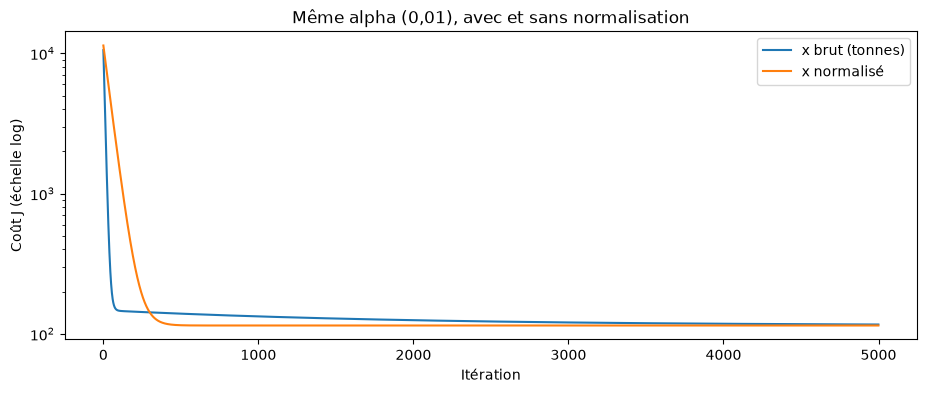

In [44]:
plt.figure(figsize=(11, 4))

for etiquette, x_used in [("brut (tonnes)", x_go), ("normalisé", x_norm)]:
    _, _, J = gradient_descent(x_used, y_go, 0, 0, 0.01, 5000,
                               compute_cost, compute_gradient, verbose=False)
    plt.plot(J, label=f"x {etiquette}")

plt.yscale("log")
plt.xlabel("Itération"); plt.ylabel("Coût J (échelle log)")
plt.title("Même alpha (0,01), avec et sans normalisation")
plt.legend(); plt.show()

**Point d'attention :**

les `w` et `b` obtenus sur données normalisées ne sont plus interprétables directement — ils portent sur les unités transformées. Il faut les reconvertir pour retrouver mes « 84 g par tonne ».

In [45]:
mu, sigma = x_go.mean(), x_go.std()
w_orig = w / sigma
b_orig = b - w * mu / sigma
print(f"w={w_orig:.2f}, b={b_orig:.2f}")

w=83.65, b=-11.09


## Ce que je retiens de la semaine 1

**Sur les données.** Une variable ne suffit pas, et les deux motorisations le disent différemment : le diesel par une erreur qui croît avec la masse, l'essence par une famille entière de véhicules — les sportives — que le modèle ignore. La régression multiple (semaine 2) répond exactement à ce problème : en ajoutant `puiss_max`, les résidus des sportives devraient chuter. C'est l'hypothèse que testera le notebook suivant.

**Sur l'algorithme.** La descente de gradient retrouve bien les paramètres de scikit-learn, mais rien n'est gratuit : le taux d'apprentissage se situe dans une fenêtre étroite — trop petit, on n'arrive jamais ; trop grand, tout diverge en `nan` en quelques milliers d'itérations. Et la normalisation, que je croyais réservée aux problèmes multi-variables, s'est révélée décisive avec une seule variable.

**Ce que ça change pour la suite.** Normaliser par défaut, mais conserver `mu` et `sigma` — les paramètres appris portent sur les variables transformées, et il faut savoir revenir aux grammes par tonne. En semaine 2, avec plusieurs variables d'échelles très différentes (masse en tonnes, puissance en kW), ce réflexe ne sera plus optionnel.